In [1]:
import napari
import numpy as np
from skimage.io import imread
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
import os
import tqdm
import glob

%matplotlib inline

In [5]:
fig_out_folder = './figures/'
isExist = os.path.exists(fig_out_folder)
if not isExist:

   # Create a new directory because it does not exist
   os.makedirs(fig_out_folder)

In [6]:
folder = '../../IMC_SegmentationResults/Leap001/'
file_name = 'Leap001_008.tiff'
img = imread(folder+'img/'+file_name)
panel = pd.read_csv(folder+'panel.csv')
panel = panel[panel.keep==1]
panel.name = panel.name.str.split('-',n=1).str.get(1)
panel.reset_index(drop = True,inplace=True)


This script reads the file img data, and shows in napari with the protein tag

In [5]:

#viewer = napari.Viewer()
#layer = viewer.add_image(img, name=panel.name,channel_axis=0)
!ls ../../combined_tiff

Leap001    Leap009  Leap025  Leap039  Leap051  Leap058	Leap069  Leap082
Leap002    Leap010  Leap028  Leap041  Leap052  Leap059	Leap070  Leap083
Leap004    Leap011  Leap030  Leap042  Leap053  Leap061	Leap071  Leap084
Leap004_2  Leap013  Leap033  Leap043  Leap054  Leap062	Leap074  Leap085
Leap005    Leap014  Leap034  Leap045  Leap055  Leap064	Leap076  Leap086
Leap006    Leap015  Leap035  Leap048  Leap056  Leap066	Leap078  Leap091
Leap008    Leap016  Leap037  Leap049  Leap057  Leap068	Leap080  Leap093


In [18]:
path0 = '../../'
base_dir = path0+'combined_tiff'

sub_dir_pattern = os.path.join(base_dir, 'Leap*')
file_pattern = '*.tiff'
tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
tb['Leap_ID'] = tb.filepath.str.replace(base_dir+'/','').str.split('/').str[0]
tb.head()
panel = pd.read_csv(base_dir+'/Leap001/panel.csv',index_col=0)
panel = panel[panel.keep]

37

In [25]:
corr=corr/n

/tmp/ipykernel_314459/1480643610.py:1: RuntimeWarning: divide by zero encountered in divide
  corr=corr/n


In [62]:
corr = np.zeros((panel.keep.sum(),panel.keep.sum()))
n = 0#counter for the number of items
for file in tqdm.tqdm(tb.filepath):
    img = imread(file)
    reshaped_data = img.reshape(img.shape[0],-1)
    temp = np.corrcoef(reshaped_data)
    corr+=temp
    if np.any(temp>1):
        raise ValueError
    n+=1
corr=corr/n

100%|█████████████████████████████████████████| 542/542 [01:22<00:00,  6.55it/s]


In [65]:
corr_pd = pd.DataFrame(corr,index = panel.name,columns=panel.name)
np.fill_diagonal?

<Figure size 640x480 with 0 Axes>

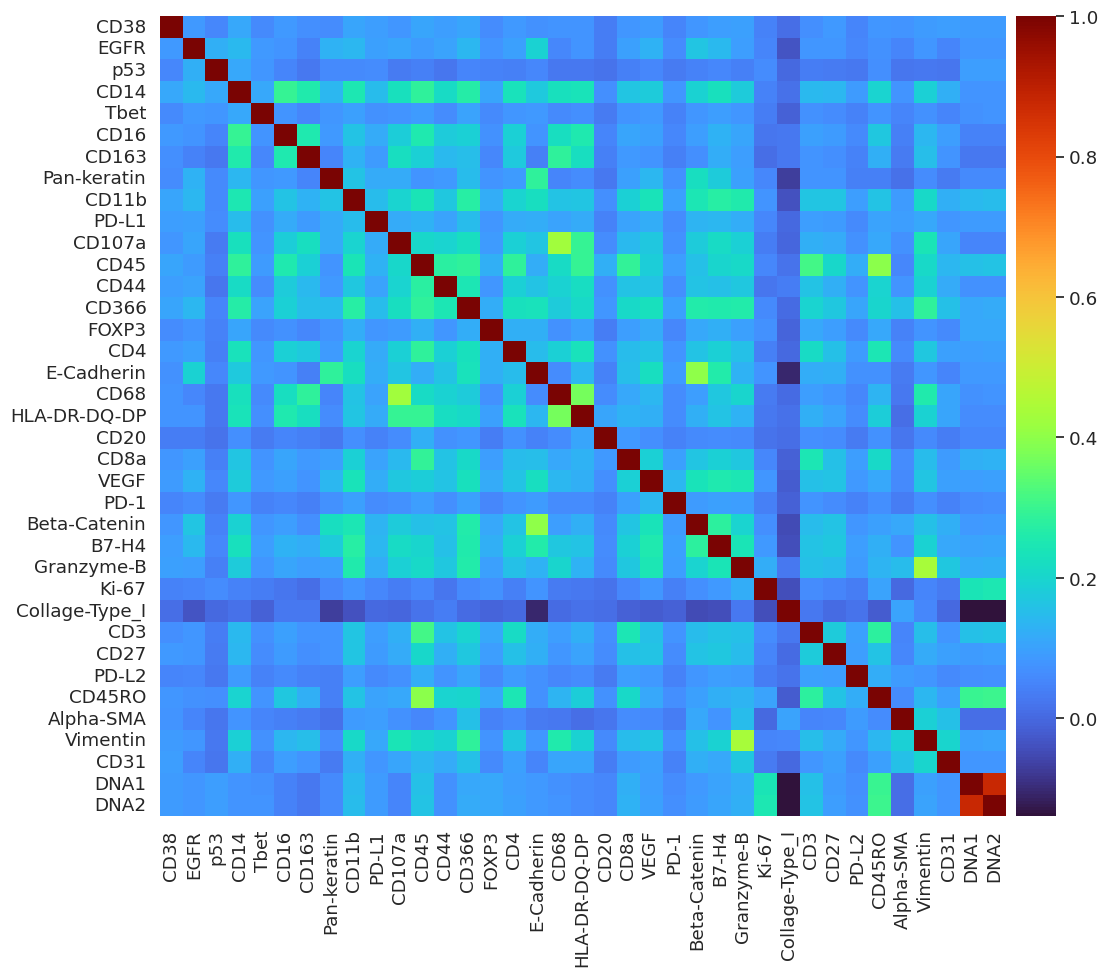

In [64]:
plt.tight_layout()
sns.set(font_scale=1.2)
plt.figure(figsize=(12,10))
ax = sns.heatmap(corr_pd,cmap='turbo',cbar_kws={'pad':0.01})
ax.set(xlabel=None)
ax.set(ylabel=None)
plt.tight_layout()
plt.savefig(fig_out_folder+'all_marker.png')

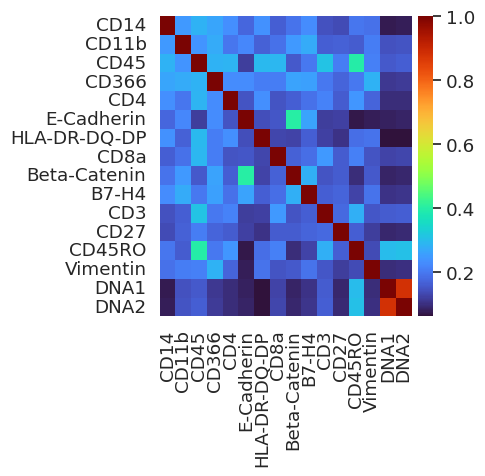

In [78]:
membrane_markers = ['CD14', 'CD11b', 'CD45', 'CD366', 'CD4', 'E-Cadherin',
       'HLA-DR-DQ-DP', 'CD8a', 'Beta-Catenin', 'B7-H4', 'CD3', 'CD27',
       'CD45RO', 'Vimentin']
nucl_markers = ['DNA1','DNA2']

segm_markers = membrane_markers+nucl_markers
plt.figure(figsize=(5,5))
ax = sns.heatmap(corr_pd.loc[segm_markers,segm_markers],cmap='turbo',cbar_kws={'pad':0.02})
ax.set(xlabel=None)
ax.set(ylabel=None)
plt.tight_layout()
plt.savefig(fig_out_folder+'our_marker.png')

# Creating the nuclei and membrane mask

Rescale cythoplasm marker expression and take the average

In [140]:
def create_image_file_record(membrane_markers,nucl_markers):
    path0 = '../../'
    panel = pd.read_csv(path0+'/combined_tiff/Leap001/panel.csv',index_col=0)
    panel = panel[panel.keep]
    base_dir = path0+'split_channels'
    file_pattern = '*.tiff'  # Change to '*.tif' if your files have the '.tif' extension

    # Create a pattern to search for subdirectories with names starting with 'Leap'
    sub_dir_pattern = os.path.join(base_dir, 'Leap*')
    tb = pd.DataFrame(glob.glob(os.path.join(sub_dir_pattern, file_pattern), recursive=True),columns = ['filepath'])
    acq_mark = pd.DataFrame(list(tb.filepath.str.split('/').str[-2:]),columns = ['acquisition','marker'])
    acq_mark['marker'] = acq_mark.marker.str.rstrip('.tiff')
    tb = pd.concat([tb,acq_mark],axis=1)
    tb = tb[tb.marker.isin(membrane_markers+nucl_markers)].reset_index(drop = True)#restrict to segmentation markers only

    tb['membrane'] = tb.marker.isin(membrane_markers)
    tb['acquisition_ID'] = tb.filepath.str.split('/').str[-2]
    return tb
def load_imgs_and_concatenate(tb_subset,smoothing_factor=0):
    '''Load a series of images, rescale, and adds them up '''
    img_out = np.zeros((imread(tb_subset.filepath.iloc[0]).shape))
    for filepath in tb_subset.filepath:
        img = imread(filepath)

        img = ndimage.gaussian_filter(img,sigma = smoothing_factor)
        img_flattened = img.reshape(img.shape[0],-1) 
        img_percentile = np.quantile(img_flattened,  q= .99)
        img_out += img/img_percentile
    return img_out/len(tb_subset.filepath)

In [133]:
a = pd.read_excel(path0+'IMC_data/ExtraDocs/Deepcell_nucleuscytoplasm.xlsx')
a.name=a.name.str.split('-',n = 1).str[1]
a = a[~a.name.isna()]
segm_marker = {}
for key, ind in a.groupby('deepcell').groups.items():
    names = a.loc[ind].name.values
    if key == 1:
        segm_marker['nucleous'] = names
    elif key == 2:
            segm_marker['membrane'] = names
segm_marker['nucleous']

array(['p53', 'FOXP3', 'Ki-67', 'DNA1', 'DNA2'], dtype=object)

In [134]:
membrane_markers = ['CD14', 'CD11b', 'CD45', 'CD366', 'CD4', 'E-Cadherin',
       'HLA-DR-DQ-DP', 'CD8a', 'Beta-Catenin', 'B7-H4', 'CD3', 'CD27',
       'CD45RO', 'Vimentin']
nucl_markers = ['DNA1','DNA2']
tb = create_image_file_record(membrane_markers=membrane_markers,nucl_markers=nucl_markers)

In [146]:
key,ind = list(tb.groupby('acquisition_ID').groups.items())[0]
cond = tb.loc[ind].membrane #take membrane marker
img_memb = load_imgs_and_concatenate(tb.loc[ind][cond],smoothing_factor=0)
img_nucl = load_imgs_and_concatenate(tb.loc[ind][~cond])
image = np.stack((img_nucl,img_memb),axis =-1)#stack nuclear and membrane channel on the last axis
X_train = np.expand_dims(image,axis = 0)

In [180]:
cell_membrane_markers_gpt = [
    'CD38', 'EGFR', 'CD14', 'CD16', 'CD163', 'Pan-keratin', 'CD11b',
    'CD45', 'CD44', 'CD366', 'CD20', 'CD8a', 'CD3', 'CD27', 'CD45RO',
    'CD31'
]
set(cell_membrane_markers_gpt).difference(set(membrane_markers))

{'CD16', 'CD163', 'CD20', 'CD31', 'CD38', 'CD44', 'EGFR', 'Pan-keratin'}

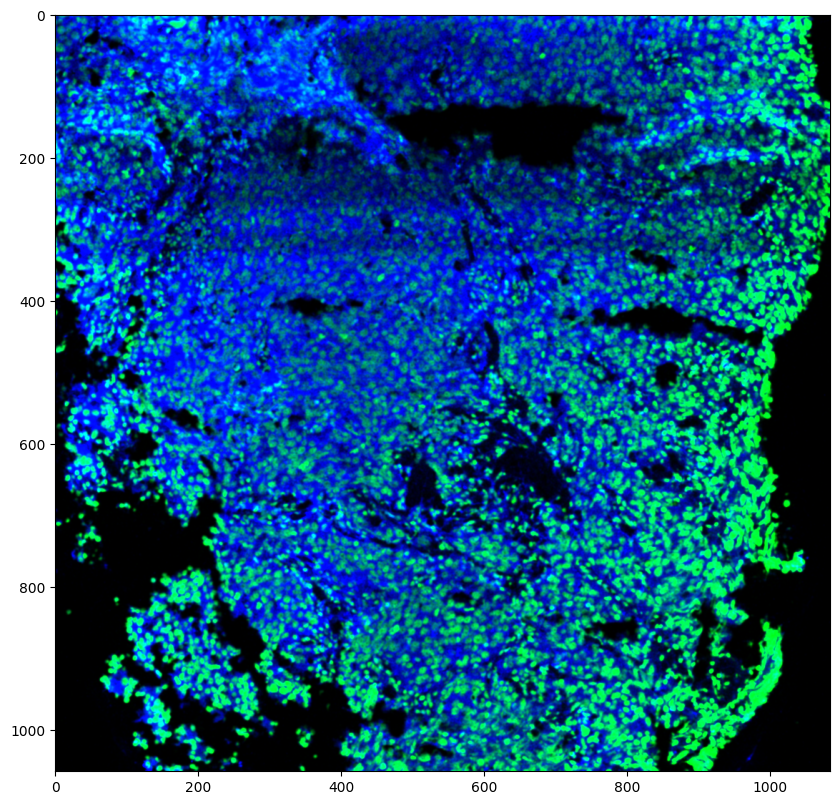

In [184]:
tb = create_image_file_record(membrane_markers=membrane_markers,nucl_markers=nucl_markers)
key,ind = list(tb.groupby('acquisition_ID').groups.items())[1]
cond = tb.loc[ind].membrane #take membrane marker
img_memb = load_imgs_and_concatenate(tb.loc[ind][cond],smoothing_factor=1)
img_nucl = load_imgs_and_concatenate(tb.loc[ind][~cond],smoothing_factor=1)
image = np.stack((img_nucl,img_memb),axis =-1)#stack nuclear and membrane channel on the last axis
X_train = np.expand_dims(image,axis = 0)
rgb_images = create_rgb_image(X_train, channel_colors=['green', 'blue'])
plt.figure(figsize = (10,10))
plt.imshow(rgb_images[0])

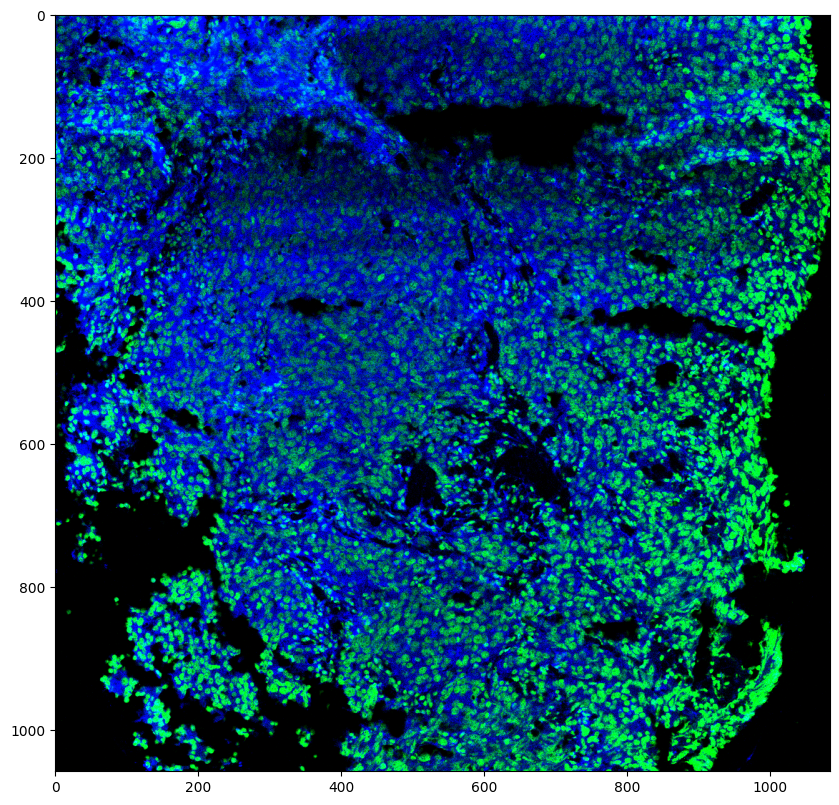

In [185]:
tb = create_image_file_record(membrane_markers=membrane_markers,nucl_markers=nucl_markers)
key,ind = list(tb.groupby('acquisition_ID').groups.items())[1]
cond = tb.loc[ind].membrane #take membrane marker
img_memb = load_imgs_and_concatenate(tb.loc[ind][cond],smoothing_factor=0)
img_nucl = load_imgs_and_concatenate(tb.loc[ind][~cond],smoothing_factor=0)
image = np.stack((img_nucl,img_memb),axis =-1)#stack nuclear and membrane channel on the last axis
X_train = np.expand_dims(image,axis = 0)
rgb_images = create_rgb_image(X_train, channel_colors=['green', 'blue'])
plt.figure(figsize = (10,10))
plt.imshow(rgb_images[0])

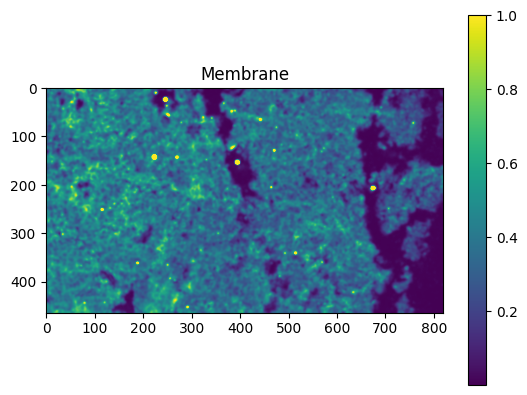

In [149]:
tb = create_image_file_record(membrane_markers=cell_membrane_markers_gpt,nucl_markers=nucl_markers)
key,ind = list(tb.groupby('acquisition_ID').groups.items())[0]
cond = tb.loc[ind].membrane #take membrane marker
img_memb = load_imgs_and_concatenate(tb.loc[ind][cond],smoothing_factor=2)

plt.title('Membrane')
plt.imshow(img_memb,vmax=1)
plt.colorbar()


In [147]:
import scipy.ndimage as ndimage
ndimage.gaussian_filter?

In [45]:
img_nucl = np.zeros((img.shape[1:]))#same x,y dimensions as per original pixel
for marker in img[panel.deepcell==1]:
    a = marker[marker>0]
    if len(a) > 0:
        img_percentile = np.quantile(a,  q= .99)
        img_nucl += marker/img_percentile
img_nucl= img_nucl/len(img[panel.deepcell==1])

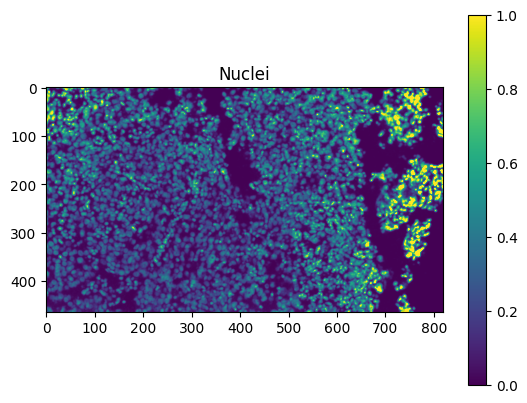

In [155]:
plt.title('Nuclei')
img_nucl = load_imgs_and_concatenate(tb.loc[ind][~cond],smoothing_factor=1)

plt.imshow(img_nucl,vmax = 1)
plt.colorbar()